## Problema e pergunta central

**Problema:** Os municípios cearenses apresentam trajetórias distintas de transformação agropecuária ao longo das últimas duas décadas, tanto em sua composição produtiva quanto na importância da agropecuária para a economia local.

**Pergunta central:** Como o perfil agropecuário dos municípios cearenses se transformou entre 2003 e 2024 e como essas mudanças se relacionam com sua estrutura econômica?

Este notebook cobre a parte de **composição pecuária**: efetivo de rebanhos por espécie, por município e ao longo do tempo — inclusive qual espécie domina o rebanho de cada município e se isso mudou entre 2003 e 2024.

## 1. Carga dos dados

### Dicionário de dados

| Coluna | Significado |
|---|---|
| `nivel_territorial_codigo` / `nivel_territorial_nome` | Nível geográfico: N1 Brasil, N3 Ceará, N6 Município |
| `territorio_codigo` | Código IBGE do território |
| `territorio_nome` | Nome do território |
| `ano_codigo` | Ano de referência (2003-2024) |
| `variavel_codigo` / `variavel_nome` | Fixa: "Efetivo dos rebanhos" |
| `unidade` | Cabeças |
| `tipo_rebanho_codigo` / `tipo_rebanho_nome` | Bovino, caprino, ovino, suíno, galináceos |
| `valor` | Valor da variável |

Fonte: IBGE/SIDRA, tabela 3939. Ceará + 184 municípios + Brasil, 2003-2024.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

AZUL = "#0B5FA5"
LARANJA = "#F28E2B"

In [2]:
ppm_path = "../dados/raw/dados_originais/t3939_ppm_efetivo_rebanhos_2003_2024_ce_br.csv"

df = pd.read_csv(ppm_path, sep=";", encoding="utf-8-sig")
df.shape
df.head(10)

,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,tipo_rebanho_codigo,tipo_rebanho_nome,valor
0,N1,Brasil,1,Brasil,2003,2003,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,195551576
1,N1,Brasil,1,Brasil,2004,2004,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,204512737
2,N1,Brasil,1,Brasil,2005,2005,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,207156696
3,N1,Brasil,1,Brasil,2006,2006,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,205886244
4,N1,Brasil,1,Brasil,2007,2007,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,199752014
5,N1,Brasil,1,Brasil,2008,2008,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,202306731
6,N1,Brasil,1,Brasil,2009,2009,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,205307954
7,N1,Brasil,1,Brasil,2010,2010,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,209541109
8,N1,Brasil,1,Brasil,2011,2011,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,212815311
9,N1,Brasil,1,Brasil,2012,2012,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,211279082


In [3]:
df.dtypes

nivel_territorial_codigo    object
nivel_territorial_nome      object
territorio_codigo            int64
territorio_nome             object
ano_codigo                   int64
ano_nome                     int64
variavel_codigo              int64
variavel_nome               object
unidade                     object
tipo_rebanho_codigo          int64
tipo_rebanho_nome           object
valor                       object
dtype: object

In [4]:
df["nivel_territorial_nome"].value_counts()

nivel_territorial_nome
Município               20240
Brasil                    110
Unidade da Federação      110
Name: count, dtype: int64

In [5]:
df["tipo_rebanho_nome"].value_counts()

tipo_rebanho_nome
Bovino                4092
Caprino               4092
Ovino                 4092
Suíno - total         4092
Galináceos - total    4092
Name: count, dtype: int64

In [6]:
df["ano_codigo"].agg(["min", "max"])

min    2003
max    2024
Name: ano_codigo, dtype: int64

## 2. Limpeza de dados

**Chave primária e duplicatas**

`territorio_codigo` + `ano_codigo` + `tipo_rebanho_codigo`
(`variavel_nome` é fixa nesse dataset — só tem "Efetivo dos rebanhos" — igual PIB, mas aqui quebra por tipo de rebanho: bovino, caprino, ovino, suíno, galináceos).

In [7]:
chave = ["territorio_codigo", "ano_codigo", "tipo_rebanho_codigo"]
df.duplicated(subset=chave).sum()

np.int64(0)

In [8]:
mask = pd.to_numeric(df["valor"], errors="coerce").isna()
mask.sum()
df.loc[mask]

,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,tipo_rebanho_codigo,tipo_rebanho_nome,valor
9738,N6,Município,2305100,Guaramiranga - CE,2017,2017,105,Efetivo dos rebanhos,Cabeças,2677,Ovino,-
9739,N6,Município,2305100,Guaramiranga - CE,2018,2018,105,Efetivo dos rebanhos,Cabeças,2677,Ovino,-
9740,N6,Município,2305100,Guaramiranga - CE,2019,2019,105,Efetivo dos rebanhos,Cabeças,2677,Ovino,-
9741,N6,Município,2305100,Guaramiranga - CE,2020,2020,105,Efetivo dos rebanhos,Cabeças,2677,Ovino,-
9742,N6,Município,2305100,Guaramiranga - CE,2021,2021,105,Efetivo dos rebanhos,Cabeças,2677,Ovino,-


**Símbolo especial SIDRA `-`**

Só 5 linhas, todas nível Município, todas rebanho Ovino — padrão IBGE `"-"` = zero exato: município sem efetivo ovino naquele ano. Aqui não tem variável tipo "rendimento" derivada de divisão, então não tem o problema do PAM — converte tudo pra `0` direto.

In [9]:
df["valor"] = pd.to_numeric(df["valor"], errors="coerce").fillna(0)
df["valor"].isna().sum()

np.int64(0)

**Nome do território e coluna redundante**

- `territorio_nome` tem sufixo `" - CE"` só nos municípios — tira pra ficar consistente com Brasil/Ceará.
- `ano_nome` é idêntico a `ano_codigo` (redundante) — confere e descarta.

In [10]:
df["territorio_nome"] = df["territorio_nome"].str.replace(r" - CE$", "", regex=True)

(df["ano_codigo"] != df["ano_nome"]).sum()

np.int64(0)

In [11]:
df = df.drop(columns=["ano_nome"])

## 3. Separação por nível territorial

In [12]:
df_brasil = df[df["nivel_territorial_nome"]=="Brasil"]
df_ce = df[df["nivel_territorial_nome"]=="Unidade da Federação"]
df_mun = df[df["nivel_territorial_nome"]=="Município"]

## 4. Exploração (matplotlib)

**1. Efetivo por tipo de rebanho, Ceará (2003-2024)**

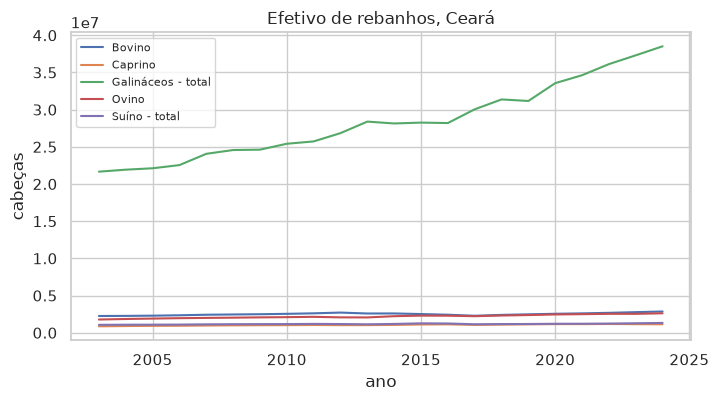

In [13]:
import matplotlib.pyplot as plt

for rebanho, grupo in df_ce.groupby("tipo_rebanho_nome"):
    plt.plot(grupo["ano_codigo"], grupo["valor"], label=rebanho)

plt.title("Efetivo de rebanhos, Ceará")
plt.xlabel("ano")
plt.ylabel("cabeças")
plt.legend(fontsize=8)
plt.show()

**2. Composição do efetivo de rebanhos, Ceará, ano mais recente**

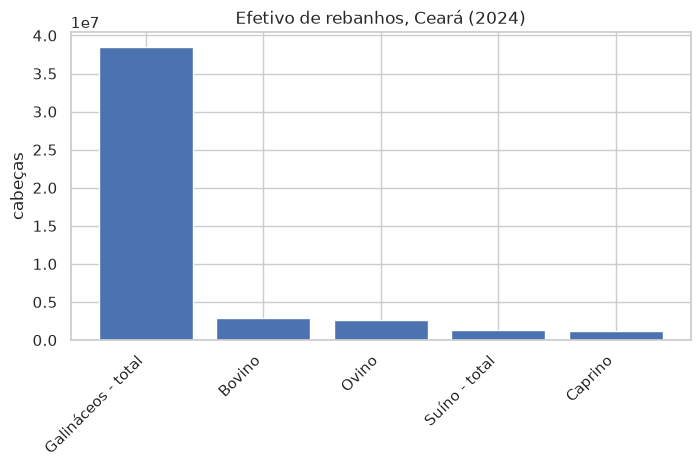

In [14]:
ano_recente = df["ano_codigo"].max()

rebanho_ce_recente = df_ce[df_ce["ano_codigo"] == ano_recente].sort_values("valor", ascending=False)

plt.bar(rebanho_ce_recente["tipo_rebanho_nome"], rebanho_ce_recente["valor"])
plt.title(f"Efetivo de rebanhos, Ceará ({ano_recente})")
plt.ylabel("cabeças")
plt.xticks(rotation=45, ha="right")
plt.show()

**3. Top 10 municípios por efetivo bovino (ano mais recente)**

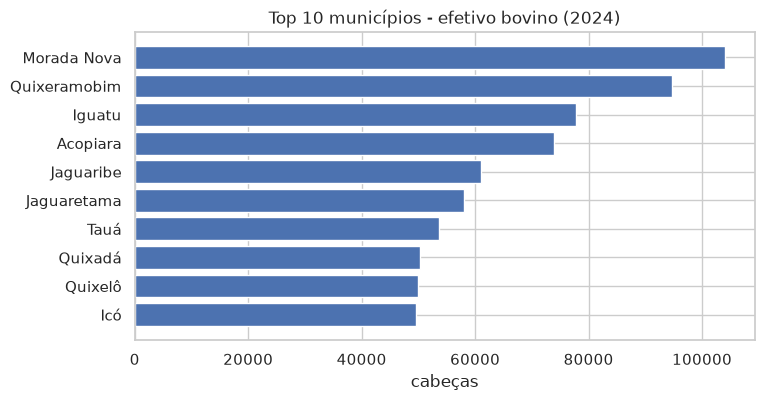

In [15]:
bovino_mun_recente = df_mun[
    (df_mun["tipo_rebanho_nome"] == "Bovino") &
    (df_mun["ano_codigo"] == ano_recente)
].sort_values("valor", ascending=False).head(10)

plt.barh(bovino_mun_recente["territorio_nome"], bovino_mun_recente["valor"])
plt.title(f"Top 10 municípios - efetivo bovino ({ano_recente})")
plt.xlabel("cabeças")
plt.gca().invert_yaxis()
plt.show()

**4. Distribuição do efetivo caprino entre municípios (ano mais recente)**

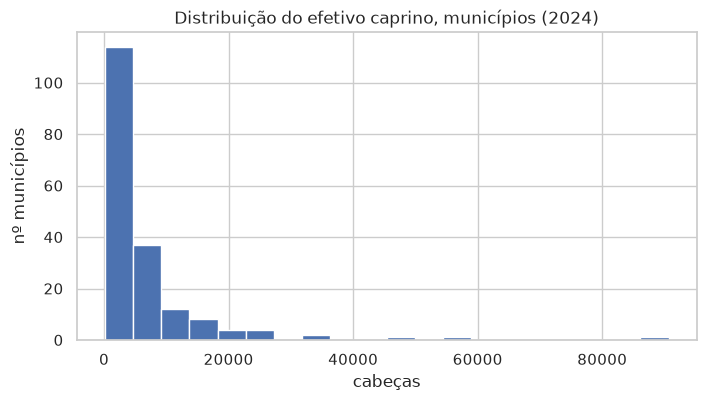

In [16]:
caprino_mun = df_mun[
    (df_mun["tipo_rebanho_nome"] == "Caprino") &
    (df_mun["ano_codigo"] == ano_recente)
]["valor"]

plt.hist(caprino_mun, bins=20)
plt.title(f"Distribuição do efetivo caprino, municípios ({ano_recente})")
plt.xlabel("cabeças")
plt.ylabel("nº municípios")
plt.show()

**5. Efetivo total de rebanhos (soma de todos os tipos), Ceará, ao longo do tempo**

Soma bruta de cabeças entre espécies diferentes (bovino + ovino + suíno + caprino + galináceos) — não pondera por peso/porte do animal, é só contagem total de cabeças no estado.

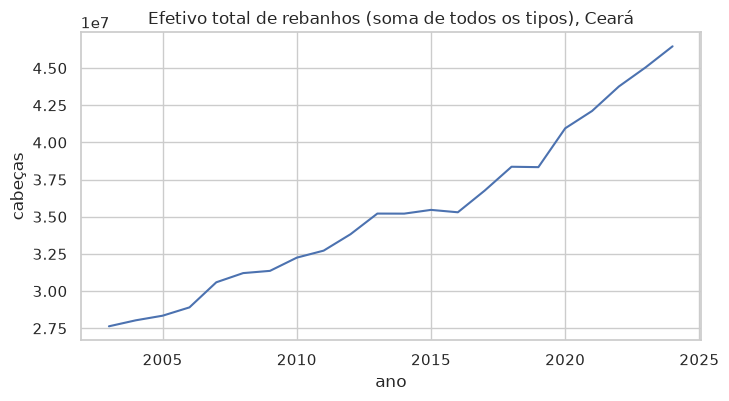

In [17]:
total_ce = df_ce.groupby("ano_codigo")["valor"].sum()

plt.plot(total_ce.index, total_ce.values)
plt.title("Efetivo total de rebanhos (soma de todos os tipos), Ceará")
plt.xlabel("ano")
plt.ylabel("cabeças")
plt.show()

**6. Top 10 municípios por efetivo total de rebanhos (soma de espécies, ano mais recente)**

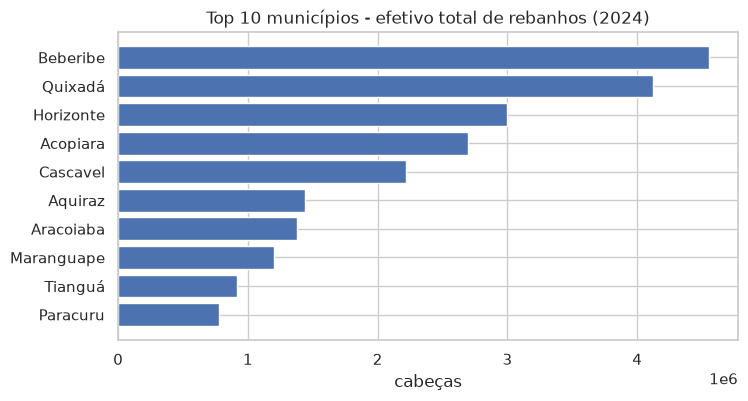

In [18]:
total_mun_recente = (
    df_mun[df_mun["ano_codigo"] == ano_recente]
    .groupby("territorio_nome")["valor"].sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.barh(total_mun_recente.index, total_mun_recente.values)
plt.title(f"Top 10 municípios - efetivo total de rebanhos ({ano_recente})")
plt.xlabel("cabeças")
plt.gca().invert_yaxis()
plt.show()

## 5. Qualidade dos dados, forma da distribuição e estatística

**7. Outliers — efetivo bovino entre municípios (ano mais recente), boxplot + IQR**

/tmp/ipykernel_96797/719431096.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(bovino_mun["valor"], vert=False)


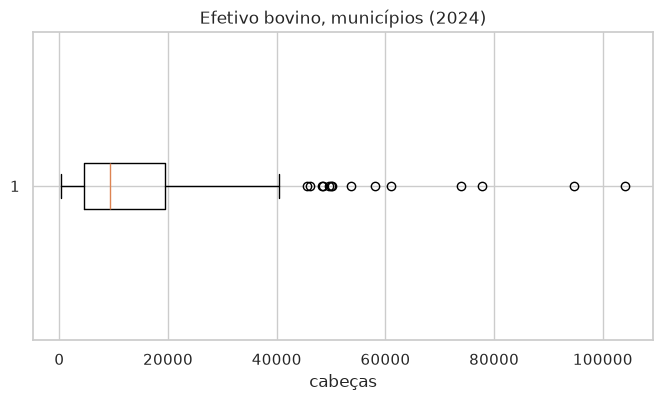

,territorio_nome,valor
2617,Morada Nova,104079.0
3365,Quixeramobim,94758.0
1737,Iguatu,77850.0
131,Acopiara,73900.0
2111,Jaguaribe,60970.0
2067,Jaguaretama,58046.0
3827,Tauá,53677.0
3321,Quixadá,50249.0
3343,Quixelô,50000.0
1715,Icó,49558.0


In [19]:
bovino_mun = df_mun[
    (df_mun["tipo_rebanho_nome"] == "Bovino") &
    (df_mun["ano_codigo"] == ano_recente)
]

plt.boxplot(bovino_mun["valor"], vert=False)
plt.title(f"Efetivo bovino, municípios ({ano_recente})")
plt.xlabel("cabeças")
plt.show()

q1, q3 = bovino_mun["valor"].quantile([0.25, 0.75])
iqr = q3 - q1
limite = q3 + 1.5 * iqr

outliers = bovino_mun[bovino_mun["valor"] > limite].sort_values("valor", ascending=False)
outliers[["territorio_nome", "valor"]]

**8. Estatística descritiva (quartis, média, desvio) — efetivo bovino, municípios**

In [20]:
bovino_mun["valor"].describe()

count       184.000000
mean      15548.635870
std       17140.106242
min         370.000000
25%        4466.500000
50%        9357.000000
75%       19417.500000
max      104079.000000
Name: valor, dtype: float64

In [21]:
bovino_mun["valor"].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.10     2080.90
0.25     4466.50
0.50     9357.00
0.75    19417.50
0.90    36258.80
0.95    49391.05
0.99    80724.36
Name: valor, dtype: float64

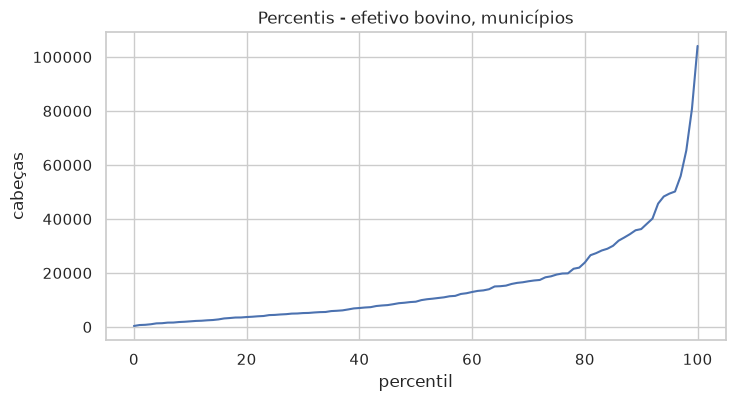

In [22]:
percentis = np.arange(0, 101)
valores_percentis = bovino_mun["valor"].quantile(percentis / 100)

plt.plot(percentis, valores_percentis)
plt.title("Percentis - efetivo bovino, municípios")
plt.xlabel("percentil")
plt.ylabel("cabeças")
plt.show()

**9. Coeficiente de variação do efetivo, por tipo de rebanho**

In [23]:
rebanho_mun_recente = df_mun[df_mun["ano_codigo"] == ano_recente]

cv_por_rebanho = rebanho_mun_recente.groupby("tipo_rebanho_nome")["valor"].agg(lambda s: s.std() / s.mean())
cv_por_rebanho.sort_values(ascending=False)

tipo_rebanho_nome
Galináceos - total    2.720684
Ovino                 1.648478
Caprino               1.624589
Bovino                1.102354
Suíno - total         1.099530
Name: valor, dtype: float64

**10. Abrangência territorial — quantos municípios criam cada tipo de rebanho (ano mais recente)**

In [24]:
abrangencia = rebanho_mun_recente[rebanho_mun_recente["valor"] > 0].groupby("tipo_rebanho_nome")["territorio_nome"].nunique()
abrangencia.sort_values(ascending=False)

tipo_rebanho_nome
Bovino                184
Caprino               184
Galináceos - total    184
Ovino                 184
Suíno - total         184
Name: territorio_nome, dtype: int64

**11. Concentração — quanto os top 10 municípios respondem do efetivo bovino total (ano mais recente)**

In [25]:
total_bovino = bovino_mun["valor"].sum()
top10_bovino = bovino_mun.sort_values("valor", ascending=False).head(10)["valor"].sum()

top10_bovino / total_bovino * 100

np.float64(23.526703901397752)

**12. Moda e média aparada — efetivo bovino, municípios**

In [26]:
medidas_centralidade = pd.DataFrame({
    "Medida": ["Média", "Mediana", "Moda", "Média aparada (10% em cada cauda)"],
    "Efetivo bovino (cabeças)": [
        bovino_mun["valor"].mean(),
        bovino_mun["valor"].median(),
        bovino_mun["valor"].mode().iloc[0],
        stats.trim_mean(bovino_mun["valor"], 0.10),
    ],
})

medidas_centralidade.round(2)

,Medida,Efetivo bovino (cabeças)
0,Média,15548.64
1,Mediana,9357.00
2,Moda,4945.00
3,Média aparada (10% em cada cauda),12293.64


**13. Intervalo interquartil (IIQ) — efetivo bovino, municípios**

In [27]:
q1, q3 = bovino_mun["valor"].quantile([0.25, 0.75])
iiq = q3 - q1
iiq

14951.0

**14. Média simples vs. média ponderada — efetivo bovino entre municípios**

Pondera pelo efetivo total de rebanhos do município (todas as espécies somadas) — município com mais rebanho no geral pesa mais. Compara com o valor agregado direto do Ceará.

In [28]:
total_por_municipio = rebanho_mun_recente.groupby("territorio_nome")["valor"].sum()
bovino_por_municipio = bovino_mun.set_index("territorio_nome")["valor"]
bovino_ce = df_ce[df_ce["tipo_rebanho_nome"] == "Bovino"]

media_simples = bovino_por_municipio.mean()
media_ponderada = np.average(bovino_por_municipio, weights=total_por_municipio.loc[bovino_por_municipio.index])
valor_ceara = bovino_ce.loc[bovino_ce["ano_codigo"] == ano_recente, "valor"].iloc[0]

comparacao_medias = pd.DataFrame({
    "Cálculo": [
        "Média simples entre municípios",
        "Média entre municípios ponderada pelo efetivo total (todas espécies)",
        "Valor agregado do Ceará (direto na tabela)",
    ],
    "Efetivo bovino": [media_simples, media_ponderada, valor_ceara],
})

comparacao_medias.round(2)

,Cálculo,Efetivo bovino
0,Média simples entre municípios,15548.64
1,Média entre municípios ponderada pelo efetivo ...,23586.05
2,Valor agregado do Ceará (direto na tabela),2860949.00


**15. Assimetria — efetivo bovino, municípios**

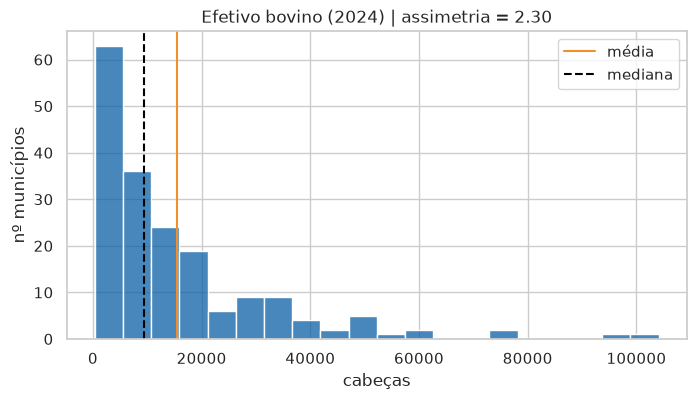

In [29]:
ax = sns.histplot(bovino_mun["valor"], color=AZUL, bins=20)
ax.axvline(bovino_mun["valor"].mean(), color=LARANJA, label="média")
ax.axvline(bovino_mun["valor"].median(), color="black", linestyle="--", label="mediana")
ax.set(
    title=f"Efetivo bovino ({ano_recente}) | assimetria = {bovino_mun['valor'].skew():.2f}",
    xlabel="cabeças", ylabel="nº municípios",
)
ax.legend()
plt.show()

**16. ECDF — efetivo bovino, municípios**

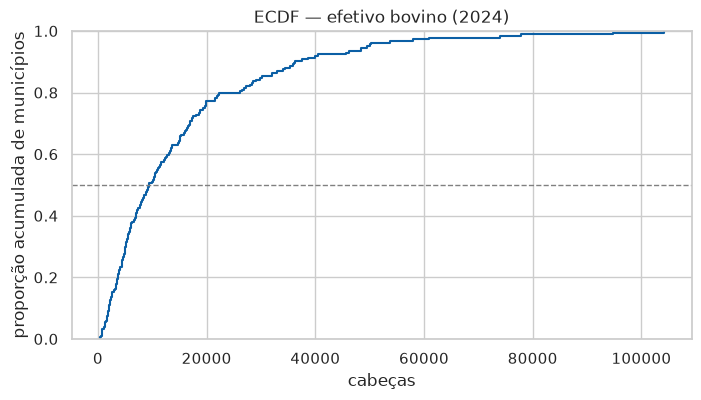

In [30]:
sns.ecdfplot(bovino_mun["valor"], color=AZUL)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.title(f"ECDF — efetivo bovino ({ano_recente})")
plt.xlabel("cabeças")
plt.ylabel("proporção acumulada de municípios")
plt.show()

**17. CCDF em escala log-log — concentração do efetivo bovino**

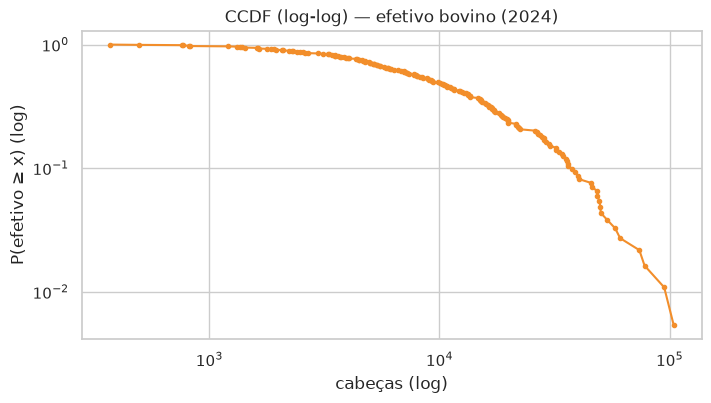

In [31]:
valores_ordenados = np.sort(bovino_mun["valor"].unique())
ccdf = [(bovino_mun["valor"] >= v).mean() for v in valores_ordenados]

plt.loglog(valores_ordenados, ccdf, "o-", color=LARANJA, markersize=3)
plt.title(f"CCDF (log-log) — efetivo bovino ({ano_recente})")
plt.xlabel("cabeças (log)")
plt.ylabel("P(efetivo ≥ x) (log)")
plt.show()

**18. Outliers por z-score (|z| > 3) — comparar com a regra IIQ do item 7**

In [32]:
z_scores = stats.zscore(bovino_mun["valor"])
outliers_z = bovino_mun[np.abs(z_scores) > 3].sort_values("valor", ascending=False)

len(outliers_z)
outliers_z[["territorio_nome", "valor"]]

,territorio_nome,valor
2617,Morada Nova,104079.0
3365,Quixeramobim,94758.0
1737,Iguatu,77850.0
131,Acopiara,73900.0


**19. Normalização — MinMax vs Standard vs Robust (efetivo bovino, municípios)**

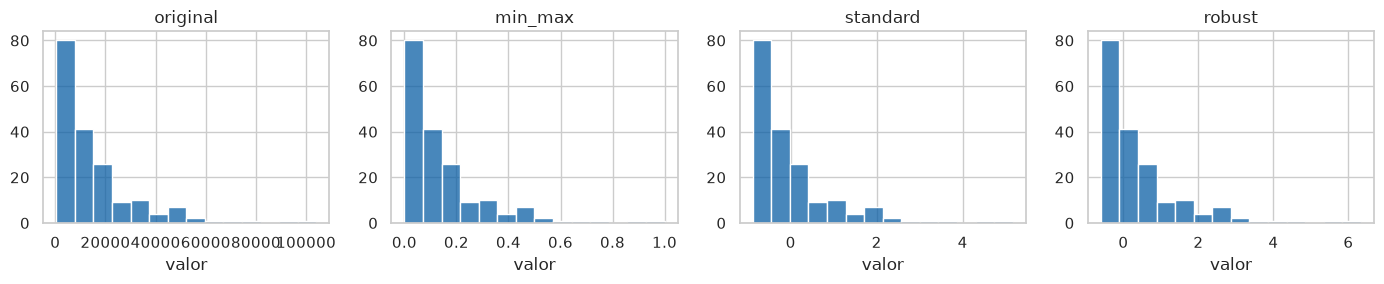

In [33]:
valor = bovino_mun["valor"]

escalas = pd.DataFrame({
    "original": valor,
    "min_max": (valor - valor.min()) / (valor.max() - valor.min()),
    "standard": (valor - valor.mean()) / valor.std(),
    "robust": (valor - valor.median()) / iiq,
})

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for coluna, ax in zip(escalas.columns, axes):
    sns.histplot(escalas[coluna], bins=14, color=AZUL, ax=ax)
    ax.set(title=coluna, xlabel="valor", ylabel="")
plt.tight_layout()
plt.show()

**20. Correlação entre tipos de rebanho (Pearson + Spearman + heatmap), municípios**

Município que cria mais bovino também cria mais das outras espécies (mistura), ou é especializado? Correlação alta entre espécies sugere municípios generalistas; baixa sugere especialização.

In [34]:
rebanho_wide = rebanho_mun_recente.pivot_table(index="territorio_nome", columns="tipo_rebanho_nome", values="valor")

pearson_vs_spearman = pd.DataFrame({
    "Pearson": rebanho_wide.corr(method="pearson")["Bovino"],
    "Spearman": rebanho_wide.corr(method="spearman")["Bovino"],
})

pearson_vs_spearman.round(3)

,Pearson,Spearman
tipo_rebanho_nome,,
Bovino,1.000,1.000
Caprino,0.474,0.616
Galináceos - total,0.141,0.425
Ovino,0.583,0.751
Suíno - total,0.416,0.560


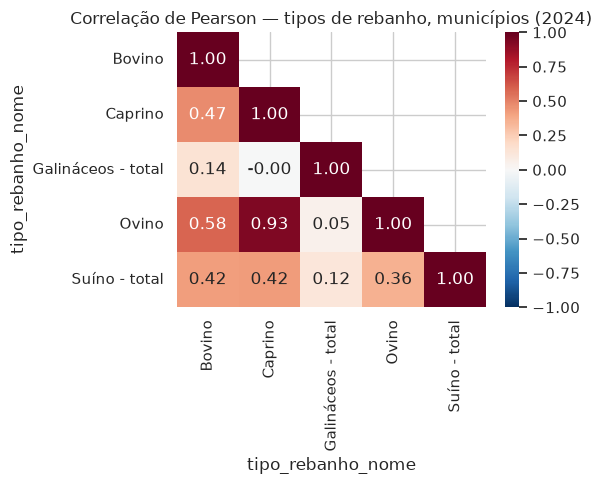

In [35]:
corr = rebanho_wide.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title(f"Correlação de Pearson — tipos de rebanho, municípios ({ano_recente})")
plt.tight_layout()
plt.show()

**21. Pairplot — tipos de rebanho, municípios**

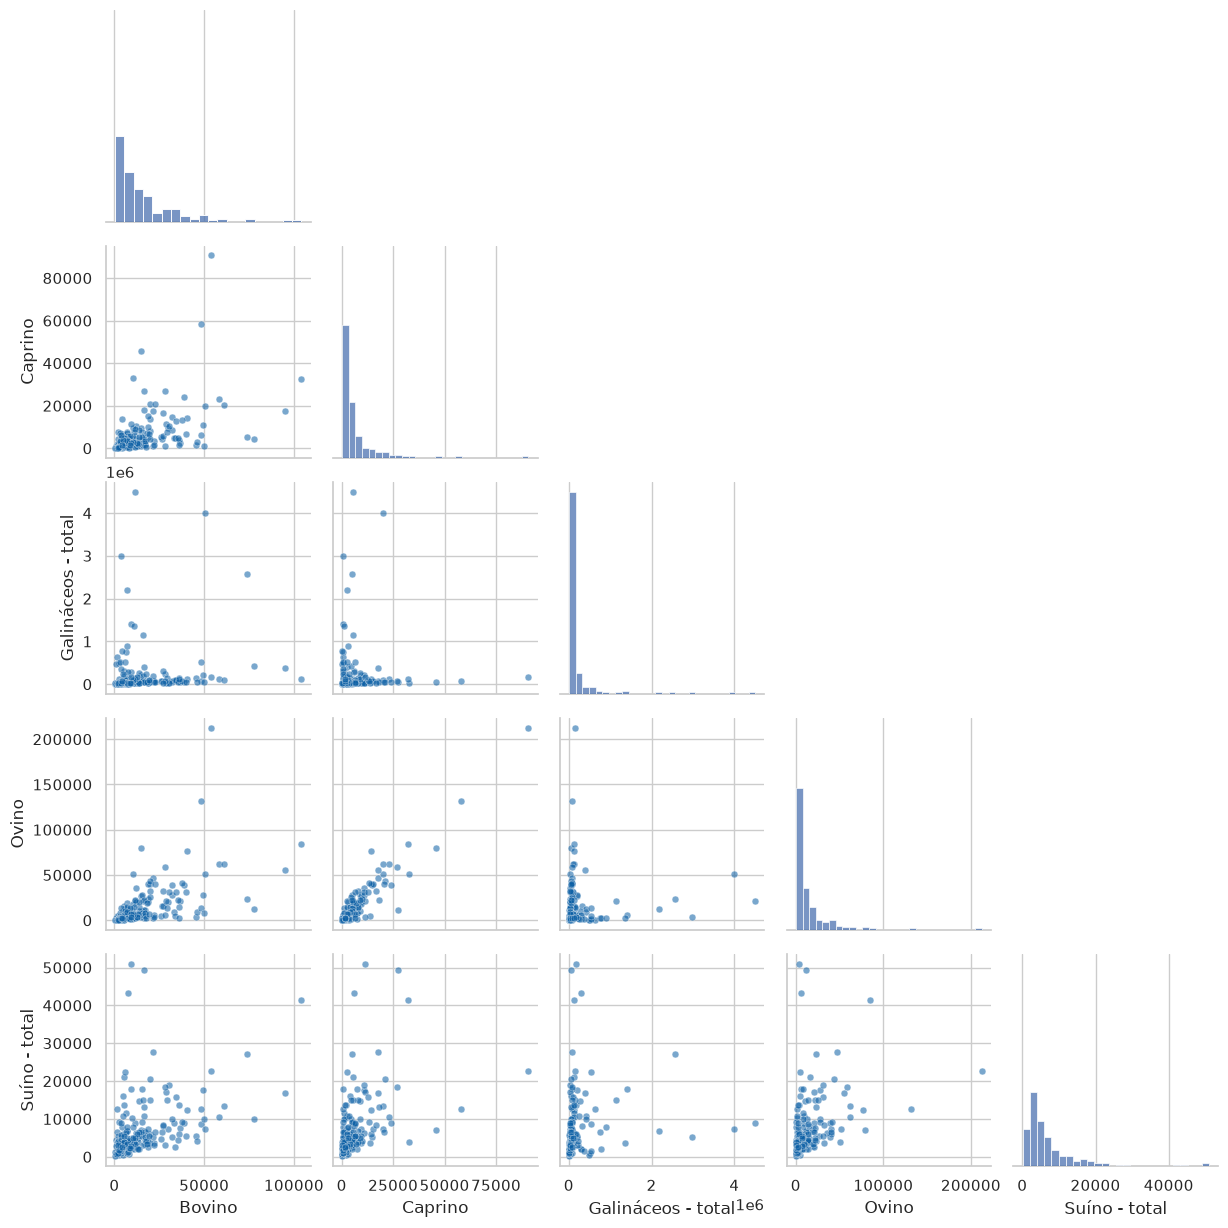

In [36]:
sns.pairplot(rebanho_wide, corner=True, diag_kind="hist", plot_kws={"alpha": 0.55, "s": 24, "color": AZUL})
plt.show()

**22. Distribuição Binomial — quantos tipos de rebanho cada município cria (de 5 possíveis)**

$n=5$ tipos de rebanho, $p$ = proporção média de municípios que criam cada tipo. Já vimos no item 10 que os 5 tipos têm abrangência de 184/184 municípios — ou seja, esperamos $p \approx 1$ e quase todo município criando os 5 tipos (distribuição bem concentrada, pouca variância).

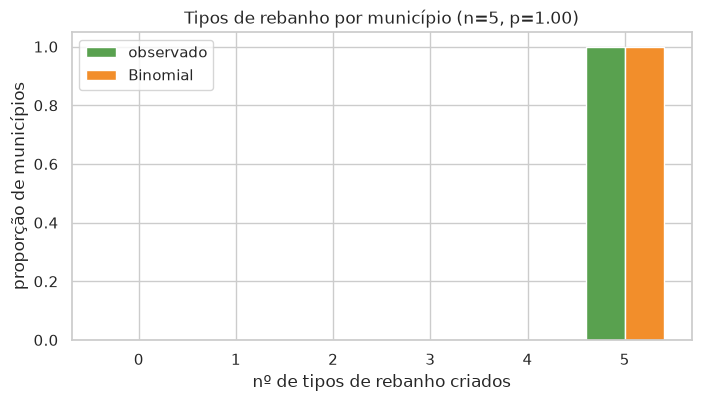

In [37]:
n_rebanhos = df["tipo_rebanho_nome"].nunique()

rebanhos_por_municipio = (
    rebanho_mun_recente.assign(criou=rebanho_mun_recente["valor"] > 0)
    .groupby("territorio_nome")["criou"].sum()
)

p_criacao = rebanhos_por_municipio.mean() / n_rebanhos
k_binomial = np.arange(n_rebanhos + 1)

frequencia_observada = rebanhos_por_municipio.value_counts(normalize=True).reindex(k_binomial, fill_value=0)

plt.bar(k_binomial - 0.2, frequencia_observada, width=0.4, label="observado", color="#59A14F")
plt.bar(k_binomial + 0.2, stats.binom.pmf(k_binomial, n=n_rebanhos, p=p_criacao), width=0.4, label="Binomial", color=LARANJA)
plt.xlabel("nº de tipos de rebanho criados")
plt.ylabel("proporção de municípios")
plt.title(f"Tipos de rebanho por município (n={n_rebanhos}, p={p_criacao:.2f})")
plt.legend()
plt.show()

**23. Distribuição de Poisson — mesmo dado, pra comparar**

Suporte infinito, mas aqui o teto real é 5. Aproximação pior que a Binomial pra essa variável.

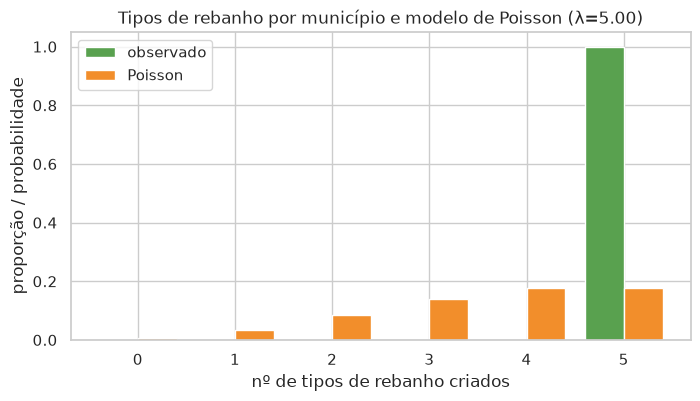

In [38]:
lambda_rebanhos = rebanhos_por_municipio.mean()

plt.bar(k_binomial - 0.2, frequencia_observada, width=0.4, label="observado", color="#59A14F")
plt.bar(k_binomial + 0.2, stats.poisson.pmf(k_binomial, mu=lambda_rebanhos), width=0.4, label="Poisson", color=LARANJA)
plt.xlabel("nº de tipos de rebanho criados")
plt.ylabel("proporção / probabilidade")
plt.title(f"Tipos de rebanho por município e modelo de Poisson (λ={lambda_rebanhos:.2f})")
plt.legend()
plt.show()

**24. Transformação da composição pecuária — rebanho dominante por município, 2003 vs 2024**

Pra cada município, qual das 5 espécies tem maior efetivo — e se essa "espécie dominante" mudou entre 2003 e 2024. Responde diretamente à pergunta central: como a composição pecuária mudou.

In [39]:
def rebanho_dominante(ano):
    sub = df_mun[df_mun["ano_codigo"] == ano]
    idx = sub.groupby("territorio_nome")["valor"].idxmax()
    return sub.loc[idx].set_index("territorio_nome")["tipo_rebanho_nome"]

dominante_2003 = rebanho_dominante(2003)
dominante_recente = rebanho_dominante(ano_recente)

composicao_pecuaria = pd.DataFrame({"2003": dominante_2003, ano_recente: dominante_recente})
mudou = composicao_pecuaria["2003"] != composicao_pecuaria[ano_recente]

print(f"municípios que mudaram a espécie dominante: {mudou.sum()} de {len(composicao_pecuaria)} ({mudou.mean()*100:.1f}%)")
composicao_pecuaria[mudou].head(15)

municípios que mudaram a espécie dominante: 10 de 184 (5.4%)


,2003,2024
territorio_nome,,
Acarape,Bovino,Galináceos - total
Aiuaba,Galináceos - total,Ovino
Alto Santo,Bovino,Galináceos - total
Antonina do Norte,Galináceos - total,Ovino
Catarina,Galináceos - total,Ovino
Catunda,Galináceos - total,Ovino
Ibicuitinga,Galináceos - total,Ovino
Independência,Galináceos - total,Ovino
Tabuleiro do Norte,Galináceos - total,Ovino


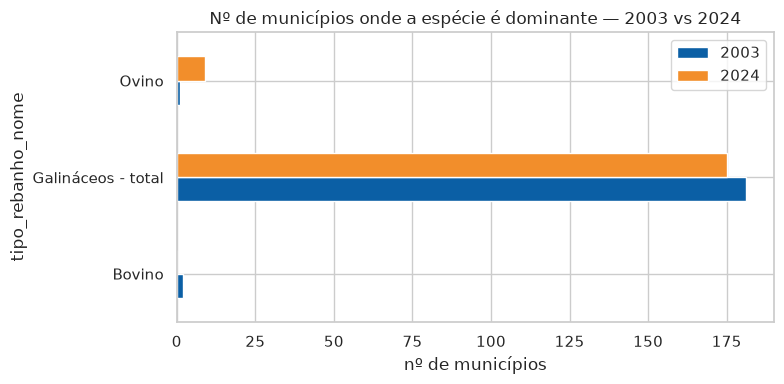

In [40]:
contagem_2003 = dominante_2003.value_counts()
contagem_recente = dominante_recente.value_counts()

comparacao_contagem = pd.DataFrame({"2003": contagem_2003, ano_recente: contagem_recente}).fillna(0)

comparacao_contagem.plot(kind="barh", color=[AZUL, LARANJA])
plt.title("Nº de municípios onde a espécie é dominante — 2003 vs " + str(ano_recente))
plt.xlabel("nº de municípios")
plt.tight_layout()
plt.show()

## Resumo

| Técnica | Onde usamos | Cuidado |
|---|---|---|
| Média, mediana, moda, média aparada | Item 8, 12 | Moda pode ser pouco informativa se poucos valores repetem |
| Média ponderada | Item 14 | Peso pelo efetivo total (todas espécies), não simples contagem |
| Quartis, percentis, IIQ | Item 8, 13 | Método de interpolação pode mudar o resultado |
| Boxplot + regra IIQ | Item 7 | Sinaliza, não decide sozinho se é erro |
| z-score | Item 18 | Sensível quando a distribuição já é assimétrica |
| Assimetria (`skew`) | Item 15 | Não substitui olhar o histograma |
| ECDF | Item 16 | Outra forma de ver os percentis |
| CCDF log-log | Item 17 | Reta no gráfico é indício, não prova de Pareto |
| Normalização (MinMax/Standard/Robust) | Item 19 | Muda escala, não muda outliers nem forma |
| Pearson vs Spearman | Item 20 | Divergência = relação não-linear |
| Heatmap / Pairplot | Item 20, 21 | Correlação não é causalidade; município generalista vs especializado |
| Binomial | Item 22 | n=5 (tipos de rebanho); esperado p≈1 (abrangência quase total, item 10) |
| Poisson | Item 23 | Suporte infinito, encaixe pior que Binomial pra essa variável |
| Exponencial | não aplicada | Modela tempo contínuo entre eventos; nosso dado é anual agregado, não tem essa granularidade |
| Transformação (dominante 2003 vs recente) | Item 24 | Responde diretamente à pergunta central — mudança de composição, não só de volume |

## 6. Salvar em `processed`

`df` já limpo (símbolo especial tratado, nome sem sufixo, coluna redundante removida) — salva em parquet, não mexe no `raw`.

In [41]:
df.to_parquet("../dados/processed/ppm_rebanhos.parquet", index=False)